We are using the theta method, an implicit method for solving ODEs. We apply the fourier transform to the cahn-hilliard equation giving us a linear expression for the time derivative of u. This can be concidered as our F(t, U). 
$$
\partial_{t}\hat{u} = \hat{g} - \kappa |\tilde{k}|^2\hat{u}
$$


As we are using an implicit method, we solve U(n+1) as shown in the theory. 

The code initially finds the sampling frequencies, then find the starting point in fourier space U0, at t0. We then sole the time dependent part of the differential equation using the solution of the linear equation mentioned. For each time step we yield the solution and time.

    """
    $/del_{t}u^ = g^ - /kappa k˜^{2}u^$.
    Solve the transient biharmonic equation using the theta method.

    Parameters:
    ----------- 
    kappa (float): Diffusion coefficient.
    X (ndarray): 2D array of x-coordinates.
    Y (ndarray): 2D array of y-coordinates.
    U0 (ndarray): Initial condition array.
    t0 (float): Initial time.
    T (float): Final time.
    Nt (int): Number of time steps.
    g (callable, optional): Source term function g(X, Y, t). Defaults to None.

    Yields:
    -------
    tuple: A tuple containing the discrete Fourier transform of U at t, and the current time t.
    """


In [65]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fft2, ifft, ifft2, fftfreq, fftshift
import pandas as pd

In [92]:
def transient_biharmonic_solver(*, kappa, X, Y, U0, t0, T, Nt, Lx, Ly, theta=0.5, g=None):

    Nx, Ny = X.shape
    kx = fftfreq(Nx, d=Lx/Nx)*2*np.pi
    ky = fftfreq(Ny, d=Ly/Ny)*2*np.pi
    KX, KY = np.meshgrid(kx, ky, sparse=True)
    k4 = (KX**2 + KY**2)**2

    # Compute DFT of the initial value
    U_hat0 = fft2(U0)
    U_hat = U_hat0
    # Add your time-stepping loop here
    # Time stepping 
    t = t0
    dt = (T-t0)/Nt

    # For convenience when plotting, computing errors, etc., 
    # return the initial solution and initial time.
    yield U_hat0, t    
    
    while t < T-dt/2:
        # Solve for next time step and update time

        if (g):
            g_now = fft2(g(X, Y, t))
            g_next = fft2(g(X , Y, t+dt))
        else:
            g_now = np.zeros_like(U_hat)
            g_next = np.zeros_like(U_hat)
        
        U_hat = (U_hat+dt*(theta*g_next+(1-theta)*(g_now - kappa*k4 * U_hat)))/(1+dt*theta*kappa*k4)
        # g = theta*g_next +(1-theta)*g_now
        # biharmonic = kappa*k4*U_hat
        # U_hat = (U_hat + dt*(g-biharmonic))/(1+dt*theta*kappa*k4)
        

        
        t+=dt
        
        yield U_hat, t

        
        
        

In [102]:
Nx, Ny = 20, 20
Lx, Ly = 2*np.pi, 2*np.pi
lam = 4
kappa = 1
t0 = 0
T = 1

x = np.linspace(-Lx/2, Lx/2, Nx, endpoint=False)
y = np.linspace(-Ly/2, Ly/2, Ny, endpoint=False)
X, Y = np.meshgrid(x, y, indexing='ij')  # Shape: (Nx, Ny)

u_ex = lambda x, y, t: np.sin(x)*np.cos(y)*np.exp(-lam * kappa * t)

U0 = u_ex(X, Y, t0)
theta = 1
Nt = 320

solver = transient_biharmonic_solver(kappa=kappa, 
                                     X=X, Y=Y, U0=U0, 
                                     t0=t0, T=T, Nt=Nt,
                                     Lx=Lx, Ly=Ly,
                                     theta=theta,
                                     g=None)



for Uhat, t in solver:
    
    U = ifft2(Uhat).real
    Tfinal = t

Uex = u_ex(X, Y, Tfinal)

U_err = U - Uex



Error norm: 0.004597869667718711


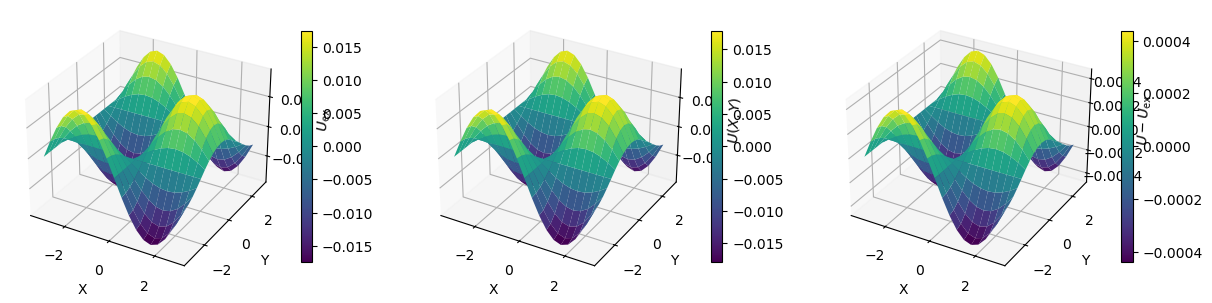

In [103]:
# Plot the solution

fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(131, projection='3d')
surf = ax.plot_surface(X, Y, Uex, cmap='viridis', antialiased=True)
fig.colorbar(surf, shrink=0.6)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel(r'$U_\mathrm{ex}$')

ax = fig.add_subplot(132, projection='3d')
surf = ax.plot_surface(X, Y, U, cmap='viridis')
fig.colorbar(surf, shrink=0.6)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel(r'$U(X, Y)$')


print(f"Error norm: {np.linalg.norm(U_err)}")
ax = fig.add_subplot(133, projection='3d')
surf = ax.plot_surface(X, Y,  U_err, cmap='viridis')
fig.colorbar(surf, shrink=0.6)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel(r'$U-U_{\mathrm{ex}}$')
plt.show()

In [ ]:
thetas = [0.5, 1]
Nts = [10, 20, 40, 80, 160, 320, 640]

errs_across_thetas = []

for theta in thetas:
    err_theta = []
    for Nt in Nts:

        solver = transient_biharmonic_solver(kappa=kappa, 
                                            X=X, Y=Y, U0=U0, 
                                            t0=t0, T=T, Nt=Nt,
                                            Lx=Lx, Ly=Ly, 
                                            theta=theta,
                                            g=None)



        for Uhat, t in solver:
            U = ifft2(Uhat).real
            Tfinal = t
            
        Uex = u_ex(X, Y, Tfinal)
        U_err = Uex - Uhat
        err_max = np.max(np.abs(U_err))
        err_theta.append(err_max)

    errs_across_thetas.append(err_theta) 


EOCs = [[]]
for i in range(len(thetas)):
    errs = np.array(errs_across_thetas[i])
    dts = (T-t0)/np.array(Nts)
    eoc = np.log(errs[1:]/errs[:-1])/np.log(dts[1:]/dts[:-1])
    EOCs.append(eoc)

In [107]:
df = pd.DataFrame()
df['EOC theta = 0.5'] = EOCs[0]
df['EOC theta = 1'] = EOCs[1]
display(df)

,EOC theta = 0.5,EOC theta = 1
0,-0.059492,0.406419
1,-0.014536,0.239452
2,-0.003613,0.131004
3,-0.000902,0.068679
4,-0.000225,0.035185
5,-0.000056,0.017811


In [108]:
# Create a dataframe
df = pd.DataFrame()

df['Nt'] = Nts

df['Error theta = 0.5'] = U_errs[0]
df['Error theta = 1'] = U_errs[1]


# show datafram in a better format
display(df)


,Nt,Error theta = 0.5,Error theta = 1
0,10,0.016761,0.018316
1,20,0.018316,0.018316
2,40,0.018316,0.018316
3,80,0.018316,0.018316
4,160,0.018316,0.018316
5,320,0.018316,0.018316
6,640,0.018316,0.018316
